In [21]:
# 

import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import os
from astropy import units as u
from astropy.coordinates import SkyCoord


In [ ]:
# use some of the exposure time from the online ETC.  https://www.eso.org/observing/etc/bin/gen/form?INS.NAME=EFOSC2+INS.MODE=spectro
# we will assume 1.0" slit, grism #7, 2x2 bining
# any seeing to maximize the chance of getting time
# bright time with FLI 0.8, airmass 1.5 and going for S/N = 5 per pixel
# we will run for V = 17, 17.5, 18, 18.5, 19, 19.5, 20
# bad seeing is 1.5", good seeing is 1.0"

# given that most of our sources are likely A and B stars we will assume a 8000K template for the ETC

magnitudes = np.arange(17, 20, 0.5) #V magnitudes
exposure_times_sn5_badseeig = [157.081, 277.885, 519.821, 1044.719, 2266.485, 12613.542]

# fit a polynomial to the bad seeing case to compute intermediate values
coeffs = np.polyfit(magnitudes, np.log10(exposure_times_sn5_badseeig), 2)
poly_bad = np.poly1d(coeffs)

exposure_times_sn5_goodseeing = [29.238, 47.450, 78.065, 227.757, 414.666, 804.997]

# will add a few more points to the good seeing case since we could take it to fainter magnitudes
# will add points up to 21 mag
# good seeing is 70%, ie., 1" seeing
magnitudes_good = np.arange(17, 21, 0.5)
exposure_times_sn5_goodseeing_longer = [29.238, 47.450, 78.065, 227.757, 414.666, 804.997, 1683.674,3775.057 ]

# fit a polynomial to the good seeing case to compute intermediate values
coeffs_good = np.polyfit(magnitudes_good, np.log10(exposure_times_sn5_goodseeing_longer), 2)
poly_good = np.poly1d(coeffs_good)

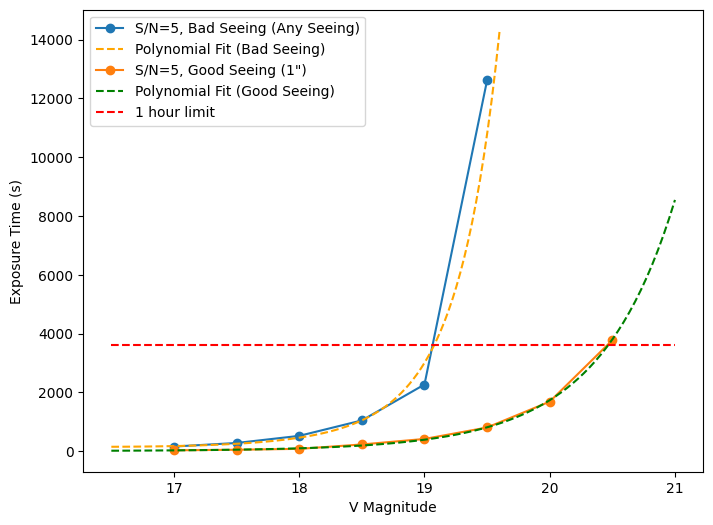

In [17]:
# plot the exposure times
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(magnitudes, exposure_times_sn5_badseeig, marker='o', label='S/N=5, Bad Seeing (Any Seeing)')
# plot the polynomial fit
mag_fit = np.linspace(16.5, 19.6, 100)
exp_fit = 10**poly_bad(mag_fit)
ax.plot(mag_fit, exp_fit, linestyle='--', color='orange', label='Polynomial Fit (Bad Seeing)')

ax.plot(magnitudes_good, exposure_times_sn5_goodseeing_longer, marker='o', label='S/N=5, Good Seeing (1")')
mag_fit_good = np.linspace(16.5, 21, 100)
ax.plot(mag_fit_good, 10**poly_good(mag_fit_good), linestyle='--', color='green', label='Polynomial Fit (Good Seeing)')

ax.set_xlabel('V Magnitude')
ax.set_ylabel('Exposure Time (s)')
ax.hlines(3600, 16.5, 21, colors='r', linestyles='--', label='1 hour limit')
ax.legend()
plt.show()

In [6]:
# compute the V magnitudes from g and r using the formula from Jester+2005
# V = g - 0.59*(g - r) - 0.01

# candidates
candidates = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/OBS_candidates.fits')

In [11]:
# compute the exposure times for each candidates
#candidates['Vmag'] = candidates['gmag'] - 0.59 * (candidates['gmag'] - candidates['rmag']) - 0.01
candidates['ExpTime_BadSeeing'] = 10**poly_bad(candidates['V'])
candidates['ExpTime_GoodSeeing'] = 10**poly_good(candidates['V'])

In [12]:
candidates

SOURCE_ID,l,b,Name,ra,ra_error,dec,dec_error,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,astrometric_params_solved,astrometric_excess_noise,astrometric_excess_noise_sig,ruwe,pseudocolour,nu_eff_used_in_astrometry,ecl_lat,phot_g_mean_mag,phot_g_mean_flux,phot_bp_mean_mag,phot_bp_mean_flux,phot_rp_mean_mag,phot_rp_mean_flux,phot_bp_rp_excess_factor,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,phot_g_mean_flux_error,phot_bp_mean_flux_error,phot_rp_mean_flux_error,bp_rp,implied_parallax,implied_parallax_error,VGCR,VR,implied_distance,implied_distance_error,A_G,A_bp,A_rp,G_corr,phot_bp_mean_mag_corr,phot_rp_mean_mag_corr,bp_rp_corr,implied_M_g,implied_M_g_corr,implied_M_g_corr_error,bp_rp_error,p_hvs,p_background,p_data,p_hvs_over_bg,healpix_pixel,3d_velocity,x,y,z,vx,vy,vz,V,best_month,best_night_min_airmass,best_night_median_airmass,best_night_hours_leq_1.8,ExpTime_BadSeeing,ExpTime_GoodSeeing
int64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,bytes9,float64,float64,float64,float64,float64
5478291327908201984,271.4857287700158,-25.999357193526823,HVS5478291327908201984,97.9240585388102,0.041436087,-61.92374480672505,0.043963168,0.1207258033480776,0.040275782,0.2688877801851139,0.07535972,5.937987677688442,0.061282694,31,0.16444387,1.8957641,1.1312152,--,1.4927549,-84.23333977432229,16.22876,6073.55086849985,16.695927,2864.484872785042,15.595039,4582.920597888446,1.2262028,6080.441,4900.7944,8251.625,5469.6978,4523.7583,6444.7417,3.6753979,15.812961,15.231415,1.1008873,0.0613467497922673,0.0035302457754293,955.559942034148,1077.1132081704657,16300.782085215684,938.0410093018536,0.1582728,0.20503905,0.12006492,16.070486,16.490887,15.474975,1.015912,0.1677175573643055,0.009444754534563,0.289213413796574,0.0069960544272924,0.8863591490811679,0.1136408509188321,0.0246190073390676,3.638079430533007,2432,955.5599420341482,-7760.402692034087,-14646.190245412294,-7125.79880870038,-411.0161244754091,-775.709791346026,-377.40544226524423,16.008622348693308,November,1.1881004304054266,1.5496710242346787,5.0,160.4828685596831,8.255119030229071
5739120950877618048,241.80190530934016,24.312569836786246,HVS5739120950877618048,138.2551236102804,0.042002633,-11.76293864518165,0.029164419,0.06755951778315075,0.057032194,-3.22317859319726,0.055882994,1.0883328678029511,0.038320757,31,0.12925032,1.2564995,1.0330276,--,1.5002569,-26.50810418265446,16.474426,4843.690389979507,16.920826,2328.553961469125,15.851845,3617.599087551005,1.227608,6466.3193,4940.2188,10738.309,5588.3813,4469.3154,6850.3477,2.1974843,11.300497,10.232179,1.0689812,0.05001037247629164,0.001851964878320016,1278.0206582197595,1419.5962786516327,19995.85187001094,740.4786955527157,0.12753907,0.16522415,0.09675046,16.346888,16.755602,15.755095,1.0005074,-0.030273284585472737,-0.15781235304593721,0.0486866987761303,0.006098688685871211,0.897380341880294,0.10261965811970597,0.32872675647248634,4.181889708662008,2548,--,--,--,--,--,--,--,16.260096096576532,April,1.0478251697067906,1.4213536979416443,4.333333333333333,150.38750274239302,11.019728524894578
5759760536477729280,234.3429127292043,28.991839929463566,HVS5759760536477729280,138.17781705820826,0.052905485,-3.621983914508915,0.05101374,0.1092929890385174,0.06478497,-3.818961866200744,0.06675453,1.2883860585011149,0.05549226,31,0.0,0.0,0.9752797,--,1.5025922,-18.824877073590297,16.838423,3463.9993556173017,17.285881,1663.659654966787,16.232069,2548.768168580295,1.2160591,5500.23,4200.691,7488.655,4954.237,4360.207

In [42]:
# now lets export a CSV file with the relevant information for the ESO proposal
# the format is Name	RA	Dec	System	pmra_arcsec	pmde_arcsec	Epoch	plx Mag	Comment,
# the Name will be the Gaia DR3 source_id
# the RA and Dec will be in hh:mm:ss in the ICRS system
# the pmra and pmdec will be in arcsec/yr
# the Epoch will be 2016.0
# the plx will be in arcsec
# the Mag will be the V magnitude we just computed and the Gaia G magnitude, the format is ((V=13.96),(G=10.78)) 

"""Option [Import Targets] is recommended for longer lists of targets. It allows you to upload a list of targets, in CSV format. The minimum set of information that needs to be specified is 'Name, RA, Dec, Mag', but a target table can include the following entries:

Name = object identifier. Each target must have a different identifier. Each identifier must include at least three characters.

RA = Right Ascension, hh:mm:ss.sss

Dec = Declination, +dd:mm:ss.ss

System = Coordinate system: J2000 (for FK5), B1950 (for FK4), ICRS. Other systems are not accepted.

Mag = magnitudes. Group them between double quotes:  "V=21.2,R=23.1,J=20.9"

Note = comment, free text.

"""


output_table = Table()
output_table['Name'] = candidates['SOURCE_ID'].astype(str)
coords = SkyCoord(ra=candidates['ra']*u.degree, dec=candidates['dec']*u.degree, frame='icrs')
output_table['RA'] = coords.ra.to_string(unit=u.hour, sep=':', pad=True, precision=3)
output_table['Dec'] = coords.dec.to_string(unit=u.degree, sep=':', pad=True, alwayssign=True, precision=2)
# homogenize the RA and Dec so that they have two digits for the seconds

output_table['System'] = 'ICRS'
output_table['Mag'] = ['V={:.2f},G={:.2f}'.format(v, g) for v, g in zip(candidates['V'], candidates['phot_g_mean_mag'])]
# the Comment will be the exposure time for good seeing of 70% turbulence, 1" seeing SNR=5 per pixel
output_table['Note'] = ['ExpTime={:.0f}s'.format(t) for t in candidates['ExpTime_GoodSeeing']]



In [43]:
output_table.write('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/targets_for_eso_proposal_p117.csv', format='csv', overwrite=True)